In [34]:
import pandas as pd

from etna.datasets import TSDataset, load_dataset
from etna.models import NaiveModel
from etna.metrics import SMAPE, WAPE
from etna.analysis import plot_forecast

# Один временной ряд

In [2]:
df = load_dataset(name="australian_wine_sales_monthly")

In [3]:
df.info()

<class 'etna.datasets.TSDataset'>
num_segments: 1
num_exogs: 0
num_regressors: 0
num_known_future: 0
freq: MS
end_timestamp: 1994-08-01 00:00:00
         start_timestamp  length  num_missing
segments                                     
main          1980-01-01     176            0


In [4]:
df.describe()
# - start_timestamp: начало сегмента, пропущенные значения в начале игнорируются;
# - end_timestamp: окончание набора данных, общее для всех сегментов;
# - length: длина в соответствии с start_timestamp и end_timestamp;
# - num_missing: количество пропущенных переменных между start_timestamp и end_timestamp;
# - num_segments: общее количество сегментов, общее для всех сегментов;
# - num_exogs: количество внешних признаков, общее для всех сегментов;
# - num_regressors: количество внешних факторов, которые являются регрессорами, общими для всех сегментов;
# - num_known_future: количество регрессоров, известных с момента создания, общее для всех сегментов;
# - freq: частота ряда, общая для всех сегментов;

,start_timestamp,end_timestamp,length,num_missing,num_segments,num_exogs,num_regressors,num_known_future,freq
segments,,,,,,,,,
main,1980-01-01,1994-08-01,176,0,1,0,0,0,MS


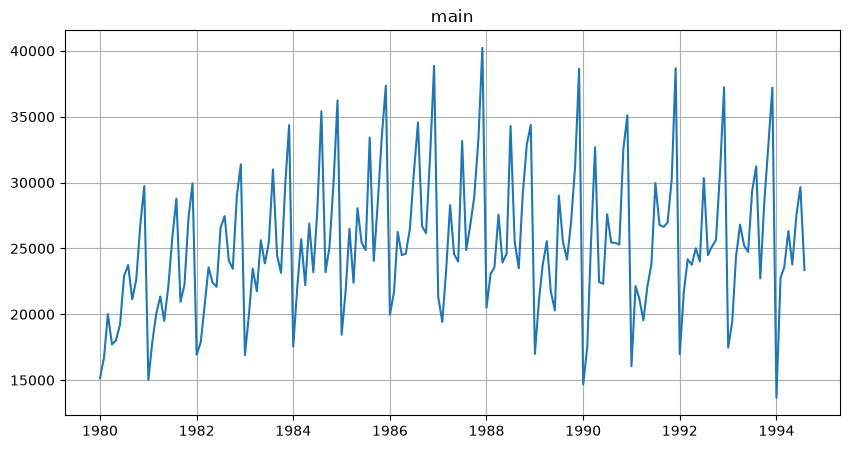

In [5]:
df.plot()

In [6]:
HORIZONT = 8 # Горизонт прогнозирования, 8 меток

df_train, df_test = df.train_test_split(
    train_start="1980-01-01",
    train_end="1993-12-01",
    test_start="1994-01-01",
    test_end="1994-08-01"
)

## `NaiveModel(lag=1)`
Начинаем с модели наивного прогноза - берем в качестве прогноза последнее известное значение.

In [7]:
model = NaiveModel()
model.fit(df_train)

NaiveModel(lag = 1, )

In [8]:
# Формируем набор меток, для которых надо получить прогнозы.
df_future = df_train.make_future(
    # Количество меток, которые хотим предсказать
    future_steps=HORIZONT,
    # Количество меток, которые используем для прогноза (контекст модели)
    # В NativeModel это 1. И это количество добавится в итоговый датафрейм
    tail_steps=model.context_size
)

df_future

segment,main
feature,target
timestamp,
1993-12-01,37198.0
1994-01-01,NaN
1994-02-01,NaN
1994-03-01,NaN
1994-04-01,NaN
1994-05-01,NaN
1994-06-01,NaN
1994-07-01,NaN


In [9]:
# Делаем прогноз.
df_forecast = model.forecast(
    # Заготовка под прогнозы с контекстом прошлого
    ts=df_future,
    # Сколько меток с КОНЦА надо отсчитать, чтобы разделить датафрейм на две части
    # - до HORIZONT - исторические данные для предсказания
    # - после HORIZONT - период на который предсказываем
    prediction_size=HORIZONT
)

# Получили прогноз, где все предсказанные метки - последнее число в обучающей выборке.
# В итоговом наборе данных нет контекста, как в df_future
df_forecast

segment,main
feature,target
timestamp,
1994-01-01,37198.0
1994-02-01,37198.0
1994-03-01,37198.0
1994-04-01,37198.0
1994-05-01,37198.0
1994-06-01,37198.0
1994-07-01,37198.0
1994-08-01,37198.0


## `NaiveModel(lag=3)`
Теперь делаем модель наивного прогноза с лагом 3. Прогнозами будут последние 3 значения.

In [10]:
model = NaiveModel(lag=3)
model.fit(df_train)

df_future = df_train.make_future(
    # Количество меток, которые хотим предсказать
    future_steps=HORIZONT,
    # Количество меток, которые используем для прогноза (контекст модели)
    # И это количество добавится в итоговый датафрейм
    tail_steps=model.context_size
)

df_forecast = model.forecast(
    # Заготовка под прогнозы с контекстом прошлого
    ts=df_future,
    # Сколько меток с КОНЦА надо отсчитать, чтобы разделить датафрейм на две части
    # - до HORIZONT - исторические данные для предсказания
    # - после HORIZONT - период на который предсказываем
    prediction_size=HORIZONT
)

# Получили прогноз, где все предсказанные метки - три последних числа в df_train
df_forecast

segment,main
feature,target
timestamp,
1994-01-01,28496.0
1994-02-01,32857.0
1994-03-01,37198.0
1994-04-01,28496.0
1994-05-01,32857.0
1994-06-01,37198.0
1994-07-01,28496.0
1994-08-01,32857.0


## `NaiveModel(lag=HORIZONT)`
Чтобы избежать дублирования предсказаний (повторения значений) в наивных моделях стоит задавать количество лагов равным горизонту прогнозирования.

In [11]:
model = NaiveModel(lag=HORIZONT)
model.fit(df_train)

df_future = df_train.make_future(
    # Количество меток, которые хотим предсказать
    future_steps=HORIZONT,
    # Количество меток, которые используем для прогноза (контекст модели)
    # И это количество добавится в итоговый датафрейм
    tail_steps=model.context_size
)

df_forecast = model.forecast(
    # Заготовка под прогнозы с контекстом прошлого
    ts=df_future,
    # Сколько меток с КОНЦА надо отсчитать, чтобы разделить датафрейм на две части
    # - до HORIZONT - исторические данные для предсказания
    # - после HORIZONT - период на который предсказываем
    prediction_size=HORIZONT
)

df_forecast

segment,main
feature,target
timestamp,
1994-01-01,25236.0
1994-02-01,24735.0
1994-03-01,29356.0
1994-04-01,31234.0
1994-05-01,22724.0
1994-06-01,28496.0
1994-07-01,32857.0
1994-08-01,37198.0


## `NaiveModel(lag=HORIZONT + N)`
Теперь соберем модель где lag будет больше целевого горизонта планированя и посмотрим, что будет с данными.

In [12]:
model = NaiveModel(lag=12)
model.fit(df_train)

df_future = df_train.make_future(
    # Количество меток, которые хотим предсказать
    future_steps=HORIZONT,
    # Количество меток, которые используем для прогноза (контекст модели)
    # И это количество добавится в итоговый датафрейм
    tail_steps=model.context_size
)

df_future

segment,main
feature,target
timestamp,
1993-01-01,17466.0
1993-02-01,19463.0
1993-03-01,24352.0
1993-04-01,26805.0
1993-05-01,25236.0
1993-06-01,24735.0
1993-07-01,29356.0
1993-08-01,31234.0


In [13]:
df_forecast = model.forecast(
    # Заготовка под прогнозы с контекстом прошлого
    ts=df_future,
    # Сколько меток с КОНЦА надо отсчитать, чтобы разделить датафрейм на две части
    # - до HORIZONT - исторические данные для предсказания
    # - после HORIZONT - период на который предсказываем
    prediction_size=HORIZONT
)


# Так как наш лаг (12) больше, чем горизонт прогнозирования (8), модель физически не может
# использовать самые свежие данные конца 1993 года (сентябрь, октябрь, ноябрь, декабрь).
# Ей приходится заглянуть в более глубокое прошлое. Разница между лагом и горизонтом: 12 - 8 = 4 шага.
# Это значит, что для построения прогноза на 8 месяцев горизонта модель возьмет отрезок длиной в 8 месяцев из истории,
# но отступив назад на 4 шага от конца тренировочной выборки.
# Конец тренировочной выборки: 1993-12-01. Отступаем 4 шага назад и получаем 1993-08-01.
# И берем 8 месяцев, предшествующих этой дате (то есть блок с января 1993 по август 1993).
df_forecast

segment,main
feature,target
timestamp,
1994-01-01,17466.0
1994-02-01,19463.0
1994-03-01,24352.0
1994-04-01,26805.0
1994-05-01,25236.0
1994-06-01,24735.0
1994-07-01,29356.0
1994-08-01,31234.0


## Оценка модели

In [14]:
smape, wape = SMAPE(), WAPE()

print(
    f"SMAPE: {smape(y_true=df_test, y_pred=df_forecast)}\n"
    f"WAPE: {wape(y_true=df_test, y_pred=df_forecast)}"
)

SMAPE: {'main': 11.492045838249387}
WAPE: {'main': 0.10938909518115258}


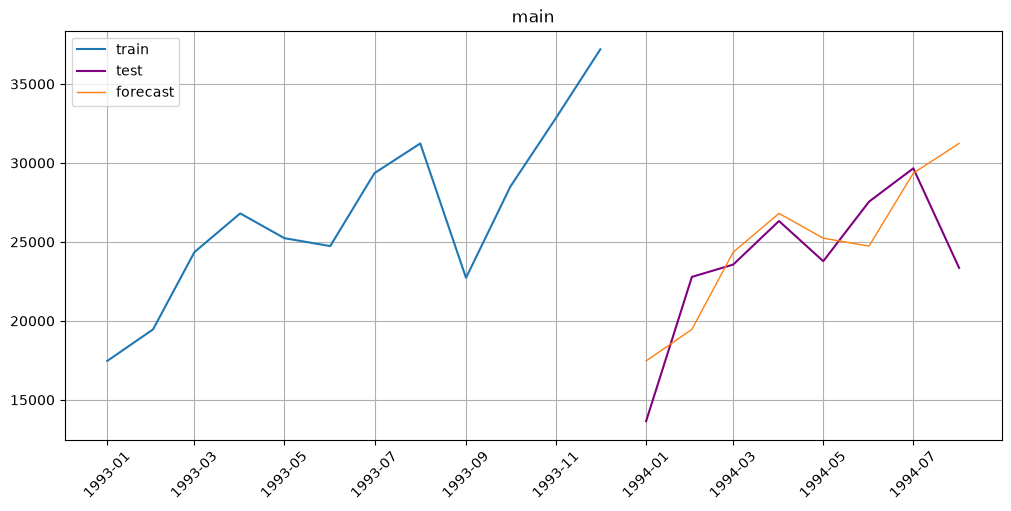

In [15]:
plot_forecast(
    train_ts=df_train,
    forecast_ts=df_forecast,
    test_ts=df_test,
    n_train_samples=12
)

# Несколько временных рядов

In [66]:
df = pd.read_csv("data/example.csv")
multi_ts = TSDataset(df=df, freq="D")
multi_ts

segment,segment_a,segment_b,segment_c,segment_d
feature,target,target,target,target
timestamp,,,,
2019-01-01,170.0,102.0,92.0,238.0
2019-01-02,243.0,123.0,107.0,358.0
2019-01-03,267.0,130.0,103.0,366.0
2019-01-04,287.0,138.0,103.0,385.0
2019-01-05,279.0,137.0,104.0,384.0
...,...,...,...,...
2019-12-27,598.0,287.0,178.0,1088.0
2019-12-28,511.0,249.0,154.0,889.0


In [67]:
multi_ts.describe()

,start_timestamp,end_timestamp,length,num_missing,num_segments,num_exogs,num_regressors,num_known_future,freq
segments,,,,,,,,,
segment_a,2019-01-01,2019-12-31,365,0,4,0,0,0,D
segment_b,2019-01-01,2019-12-31,365,0,4,0,0,0,D
segment_c,2019-01-01,2019-12-31,365,0,4,0,0,0,D
segment_d,2019-01-01,2019-12-31,365,0,4,0,0,0,D


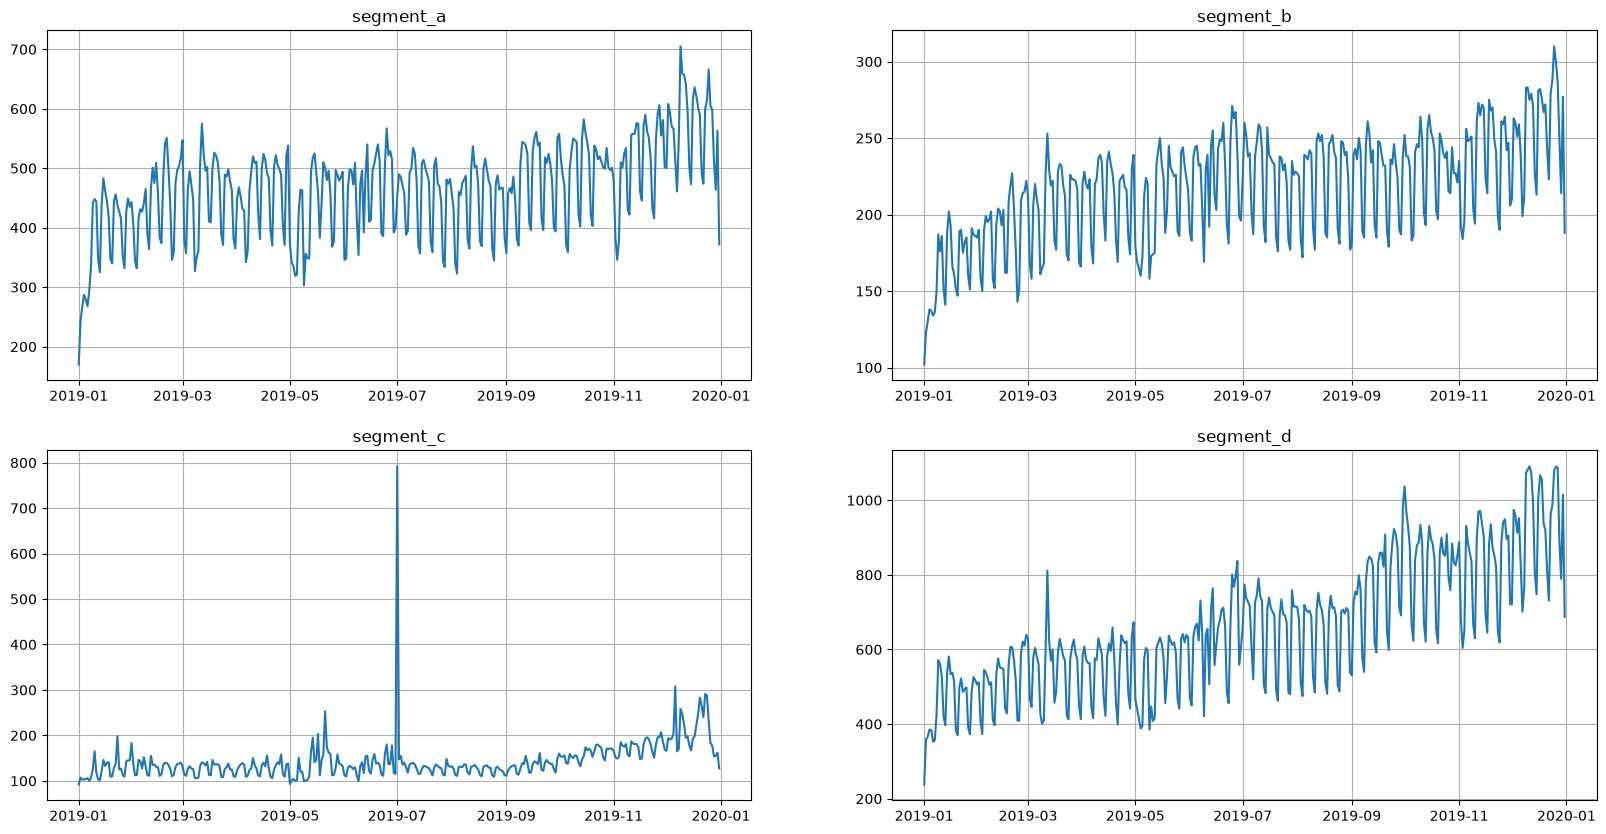

In [52]:
multi_ts.plot()

In [68]:
HORIZONT_MULTI = 7

train_ts, test_ts = ts_multi.train_test_split(
    train_start="2019-01-01",
    train_end="2019-12-24",
    test_start="2019-12-25",
    test_end="2019-12-31"
)

In [70]:
model.fit(train_ts)

future_ts = train_ts.make_future(
    # Количество меток, которые хотим предсказать
    future_steps=HORIZONT_MULTI,
    # Количество меток, которые используем для прогноза (контекст модели)
    tail_steps=model.context_size
)

forecast_ts = model.forecast(
    # Заготовка под прогнозы с контекстом прошлого
    ts=future_ts,
    # Сколько меток с КОНЦА надо отсчитать, чтобы разделить датафрейм на две части: до/после HORIZON
    prediction_size=HORIZONT_MULTI
)

forecast_ts

segment,segment_a,segment_b,segment_c,segment_d
feature,target,target,target,target
timestamp,,,,
2019-12-25,596.0,271.0,198.0,994.0
2019-12-26,502.0,227.0,178.0,808.0
2019-12-27,473.0,213.0,167.0,748.0
2019-12-28,617.0,281.0,193.0,1007.0
2019-12-29,636.0,282.0,198.0,1067.0
2019-12-30,621.0,276.0,222.0,1056.0
2019-12-31,602.0,267.0,247.0,938.0


In [71]:
smape, wape = SMAPE(), WAPE()

print(
    f"SMAPE: {smape(y_true=test_ts, y_pred=forecast_ts)}\n"
    f"WAPE: {wape(y_true=test_ts, y_pred=forecast_ts)}"
)

SMAPE: {'segment_a': 22.8767574890079, 'segment_b': 20.75869697463065, 'segment_c': 23.888994797023148, 'segment_d': 21.757368837930883}
WAPE: {'segment_a': 0.22863191320455148, 'segment_b': 0.20054794520547944, 'segment_c': 0.2619647355163728, 'segment_d': 0.21030430852666465}


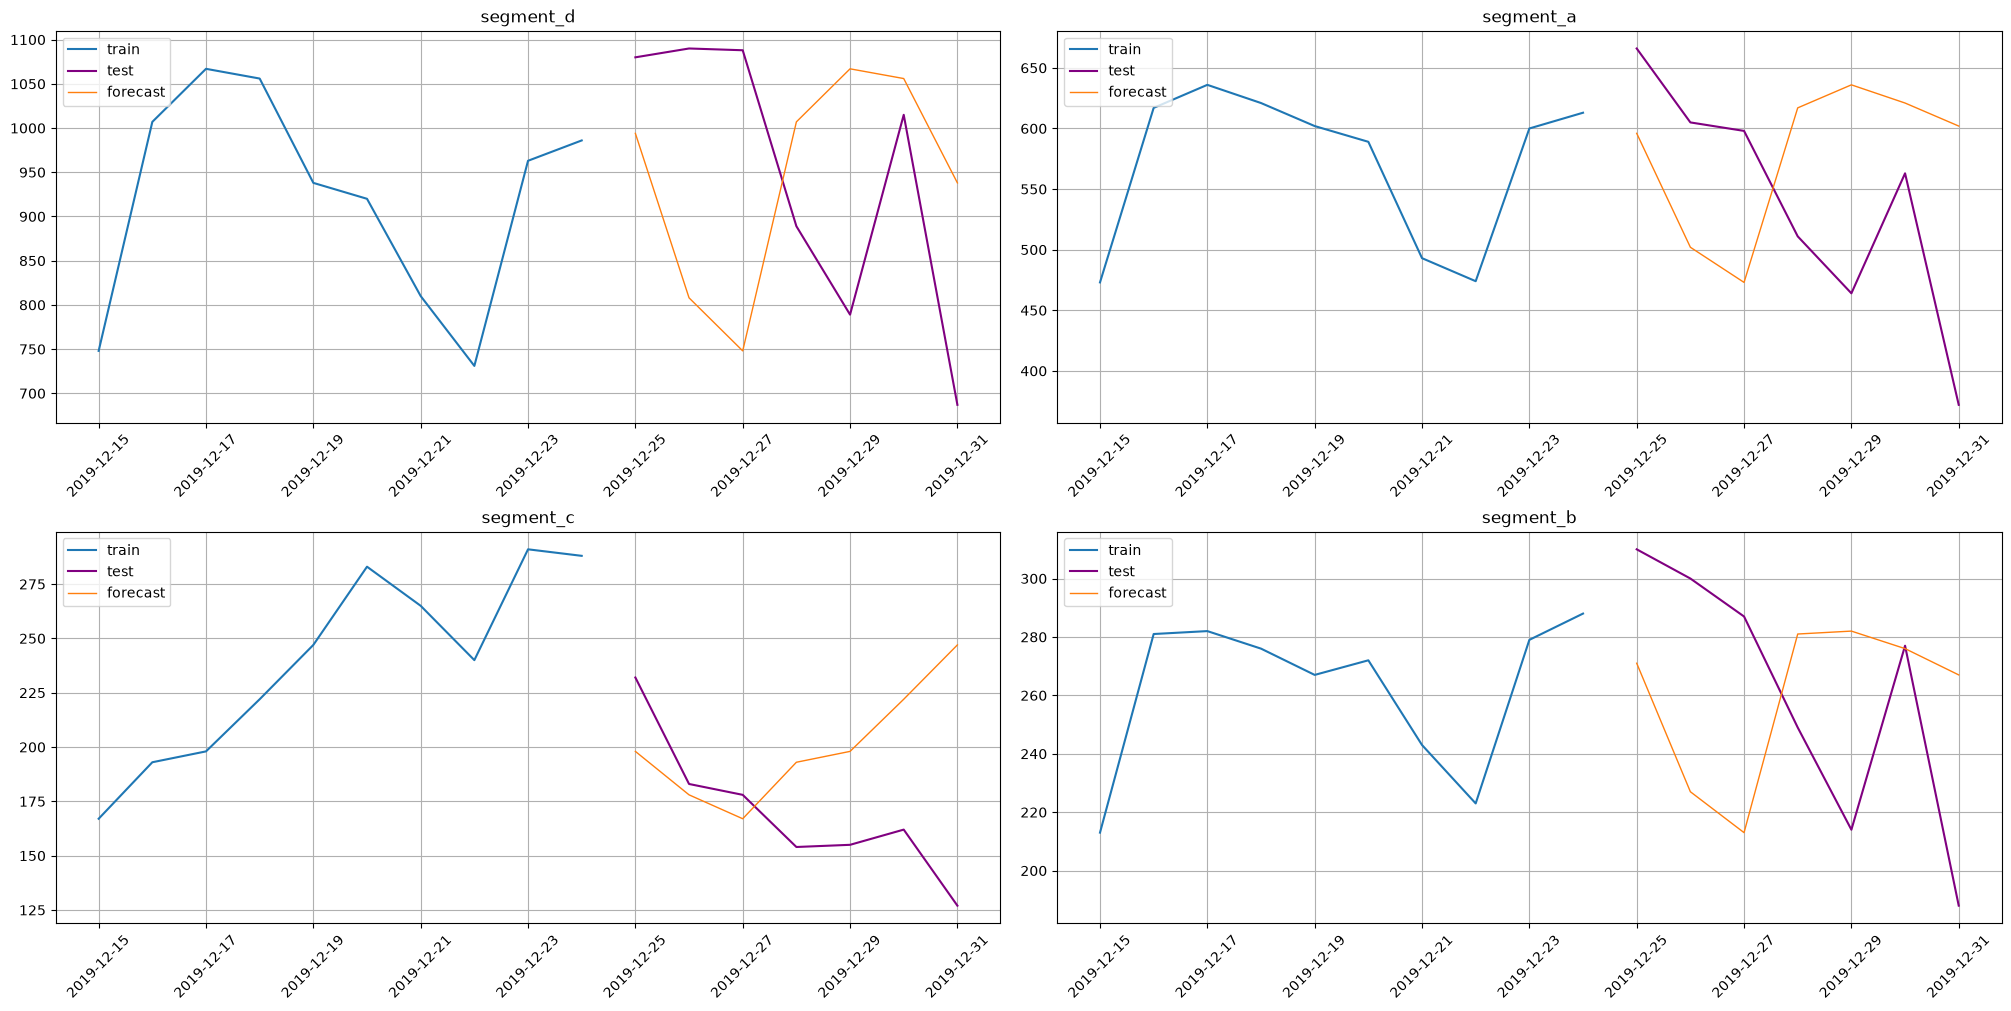

In [72]:
plot_forecast(
    train_ts=train_ts,
    test_ts=test_ts,
    forecast_ts=forecast_ts,
    n_train_samples=10
)